                                                             path recording_date                 animal surgery_date brain_region gender           partner  is_AO  notes
          2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48     2024_10_31           20240819V1r1     20240819           V1      M               NaN  False       
                2024_10_31/2social_mini_20240819V1r1_single_11_29     2024_10_31           20240819V1r1     20240819           V1      M            single  False       
             2024_11_01/2social_mini_20240819V1r1_AO_single_14_30     2024_11_01           20240819V1r1     20240819           V1      M            single   True       
              2024_11_01/2social_mini_20240910V1r_AO_single_12_50     2024_11_01            20240910V1r     20240910           V1      M            single   True       
            2024_11_07/2social_mini_20241015pmcr2_single_AO_13_24     2024_11_07          20241015pmcr2     20241015          PMC      M            single 

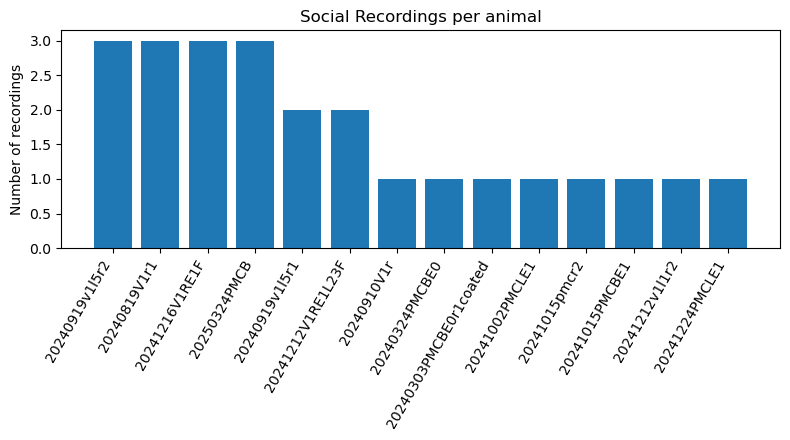

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = """
2024_10_31/2social_mini_20240819V1r1_femalebleach_11_48
2024_10_31/2social_mini_20240819V1r1_single_11_29
2024_11_01/2social_mini_20240819V1r1_AO_single_14_30
2024_11_01/2social_mini_20240910V1r_AO_single_12_50
2024_11_07/2social_mini_20241015pmcr2_single_AO_13_24
2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30
2024_12_18/20240919v1l5r2mini_p20240521b1697576_social_test_13_26
2024_12_18/20240919v1l5r2mini_p20240717PMC_social_test_13_16
2024_12_31/20240919v1l5r1mini_p20240717PMC_social_14_31
2024_12_31/20240919v1l5r2mini_p20240717PMC_social_14_04
2024_12_31/20241212v1l1r2mini_p20241111_social_12_16
2025_02_27/20241002PMCLE1mini_p20241001RE2_14_10
2025_02_27/20241015PMCBE1mini_p20241015PMCRE1_12_33
2025_03_11/20241224PMCLE1mini_p20240303PMC2_14_44
2025_04_10/20241212V1RE1L23Fmini_p20241212V1BE1L23F
2025_04_10/20241212V1RE1L23Fmini_p20241212V1LE1L23F
2025_05_01/20250324PMCBmini_psamecageBE0_14_53
2025_05_01/20250324PMCBmini_psamecageLE2_15_09
2025_05_07/20241216V1RE1Fmini_p202241216V1BE1F
2025_05_14/20240324PMCBE0mini_p20250324LE1
2025_05_14/20250324PMCBmini_p20250324LE1
2025_05_16/20240303PMCBE0r1coatedmini_p20240303RE1
2025_05_16/20241216V1RE1Fmini_p20241216RE2
2025_05_16/20241216V1RE1Fmini_p20241224PMCLE1
""".strip()

paths = [ln.strip() for ln in raw.splitlines() if ln.strip()]
df = pd.DataFrame({'path': paths})

# recording date (top-level folder)
df['recording_date'] = df['path'].str.extract(r'^(\d{4}_\d{2}_\d{2})', expand=False)

# session (string after '/')
df['session'] = df['path'].str.split('/', n=1).str[1]

# primary animal token = first token with an 8-digit surgical date; ends at '_' or '_p' or end
df['animal_raw'] = df['session'].str.extract(r'.*?(\d{8}[A-Za-z0-9]+?)(?:_p|_|$)', expand=False)

# surgery date (first 8 digits inside animal)
df['surgery_date'] = df['animal_raw'].str.extract(r'(\d{8})', expand=False)

# brain region (V1 / PMC / M1), case-insensitive
df['brain_region'] = (
    df['animal_raw']
      .str.extract(r'(V1|PMC|M1)', flags=re.IGNORECASE, expand=False)
      .str.upper()
)

# gender: 'F' before 'mini' or end => F, else M
has_F = df['animal_raw'].str.contains(r'F(?=(?:mini|$))', case=False, na=False)
df['gender'] = np.where(has_F, 'F', 'M')

# strip trailing 'mini' from animal id (case-insensitive) — only the suffix
df['animal'] = df['animal_raw'].str.replace(r'mini$', '', case=False, regex=True)

# partner: 1) after '_p' up to next '_' or end; 2) otherwise token 'single' between underscores
partner_from_p = df['session'].str.extract(r'(?<=_p)([^_]+)', expand=False)
partner_from_single = df['session'].str.extract(r'(?i)(?<=_)(single)(?=_|$)', expand=False)
df['partner'] = partner_from_p.fillna(partner_from_single)

# condition: AO only (exact token between underscores)
df['is_AO'] = df['session'].str.contains(r'(?<=_)AO(?=_)', case=False, regex=True)



# notes: catch 'coated' (add more keywords if needed)
df['notes'] = np.where(df['session'].str.contains(r'coated', case=False, na=False), 'coated', '')

# final selection
out = df[['path','recording_date','animal','surgery_date','brain_region','gender','partner','is_AO','notes']].copy()

# --- quick summaries ---
# recordings per animal
counts = (out.groupby('animal', dropna=False)
            .size()
            .reset_index(name='n_recordings')
            .sort_values('n_recordings', ascending=False))

print(out.to_string(index=False))
print("\nRecordings per animal:")
print(counts.to_string(index=False))

# --- simple visualization: bar chart of recordings per animal ---
plt.figure(figsize=(8, 4.5))
plt.bar(counts['animal'].astype(str), counts['n_recordings'])
plt.xticks(rotation=60, ha='right')
plt.ylabel('Number of recordings')
plt.title('Social Recordings per animal')
plt.tight_layout()
plt.show()

# # optionally save
# out.to_csv('social_sessions_parsed.csv', index=False)
# counts.to_csv('soscial_animal_counts.csv', index=False)


                                   path recording_date           animal surgery_date brain_region gender partner  is_AO  is_BO  notes set_name
          2024_10_14/20240916v1r1_16_37     2024_10_14     20240916v1r1     20240916           V1      M     NaN  False  False        Singles1
          2024_10_14/20240916v1r1_16_53     2024_10_14     20240916v1r1     20240916           V1      M     NaN  False  False        Singles1
          2024_10_14/20240916v1r2_14_30     2024_10_14     20240916v1r2     20240916           V1      M     NaN  False  False        Singles1
          2024_10_14/20240916v1r2_15_58     2024_10_14     20240916v1r2     20240916           V1      M     NaN  False  False        Singles1
          2024_10_17/20240819V1r1_13_41     2024_10_17     20240819V1r1     20240819           V1      M     NaN  False  False        Singles1
          2024_10_17/20240819V1r1_14_25     2024_10_17     20240819V1r1     20240819           V1      M     NaN  False  False        Singles1

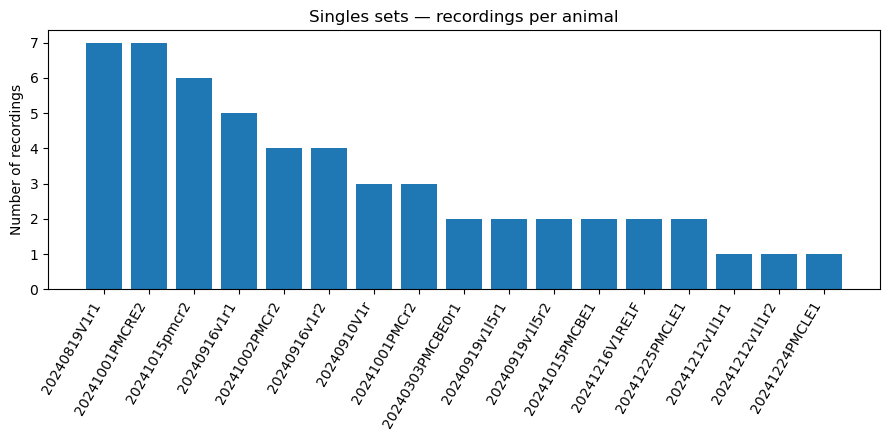

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- paste your two sets here --------
singles1_raw = """
2024_10_14/20240916v1r1_16_37
2024_10_14/20240916v1r1_16_53
2024_10_14/20240916v1r2_14_30
2024_10_14/20240916v1r2_15_58
2024_10_17/20240819V1r1_13_41
2024_10_17/20240819V1r1_14_25
2024_10_24/20241001PMCr2_16_19
2024_10_25/20241002PMCr2_16_25
2024_11_01/20240819V1r1_AO_14_56
2024_11_01/20240910V1r_AO_12_50
2024_11_06/20241015pmcr2_16_53
2024_11_06/20241015pmcr2_17_13
2024_11_07/20241015pmcr2_AO_12_52
2024_12_18/20240919v1l5r1mini_11_21
2024_12_31/20240919v1l5r2mini_13_54
2025_02_12/20241001PMCRE2mini_13_44
2025_02_12/20241001PMCRE2mini_13_57
2025_02_12/20241001PMCRE2mini_15_35
2025_02_13/20241225PMCLE1mini_11_06
2025_02_27/20241015PMCBE1mini_12_24
""".strip()

singles2_raw = """
2024_11_07/20241015pmcr2_AO_12_52
2025_02_12/20241001PMCRE2mini_15_22
2025_02_12/20241001PMCRE2mini_13_57
2025_02_12/20241001PMCRE2mini_13_44
2025_02_12/20241001PMCRE2mini_15_35
2024_10_25/20241002PMCr2_16_25
2024_10_25/20241002PMCr2_17_05
2024_10_25/20241002PMCr2_15_42
2024_12_18/20240919v1l5r1mini_11_21
2025_02_27/20241015PMCBE1mini_12_24
2025_03_11/20241224PMCLE1_14_12
2025_02_13/20241225PMCLE1mini_11_06
2024_12_31/20240919v1l5r2mini_13_54
2024_12_31/20241212v1l1r2mini_12_04
2024_12_31/20241212v1l1r1mini_11_22
2024_11_01/20240910V1r_AO_12_50
2024_11_01/20240910V1r_BO_11_35
2024_11_01/20240819V1r1_AO_14_56
2024_10_24/20241001PMCr2_15_07
2024_10_24/20241001PMCr2_16_19
2025_05_07/20241216V1RE1F
2024_10_14/20240916v1r1_14_53
2024_10_14/20240916v1r1_16_37
2024_10_14/20240916v1r2_15_58
2024_10_14/20240916v1r1_16_53
2024_10_14/20240916v1r2_14_30
2024_10_17/20240819V1r1_14_25
2024_10_17/20240819V1r1_14_40
2024_10_17/20240819V1r1_13_41
2025_05_16/20240303PMCBE0r1coated
2025_05_16/20240303PMCBE0r1coated_14_53
2025_05_16/20241216V1RE1F_15_16
2024_11_06/20241015pmcr2_17_13
2024_11_06/20241015pmcr2_16_53
""".strip()

def parse_sessions(paths, assume_single=False):
    df = pd.DataFrame({'path': [p.strip() for p in paths if p.strip()]})
    # recording date (top-level)
    df['recording_date'] = df['path'].str.extract(r'^(\d{4}_\d{2}_\d{2})', expand=False)
    # session (after '/')
    df['session'] = df['path'].str.split('/', n=1).str[1]

    # primary animal token = 8-digit date + trailing alphanumerics, up to '_p'/'_'/end
    df['animal_raw'] = df['session'].str.extract(r'(^|.*?)(\d{8}[A-Za-z0-9]+?)(?:_p|_|$)', expand=False)[1]

    # surgery date (first 8 digits)
    df['surgery_date'] = df['animal_raw'].str.extract(r'(\d{8})', expand=False)

    # brain region (V1 / PMC / M1), case-insensitive
    df['brain_region'] = (
        df['animal_raw']
          .str.extract(r'(V1|PMC|M1)', flags=re.IGNORECASE, expand=False)
          .str.upper()
    )

    # gender: F before 'mini' or end => F, else M
    has_F = df['animal_raw'].str.contains(r'F(?=(?:mini|$))', case=False, na=False)
    df['gender'] = np.where(has_F, 'F', 'M')

    # partner (if any)
    df['partner'] = df['session'].str.extract(r'_p([^_]+)', expand=False)

    # robust token checks: pad underscores to catch tokens at edges
    pad = '_' + df['session'] + '_'
    df['is_AO'] = pad.str.contains(r'_AO_', case=False, regex=True)
    df['is_BO'] = pad.str_contains(r'_BO_', case=False, regex=True) if hasattr(pad, 'str_contains') else pad.str.contains(r'_BO_', case=False, regex=True)
    # 'single' token OR override for this list
    # df['is_single'] = pad.str.contains(r'_single_', case=False, regex=True) | assume_single

    # notes (capture 'coated' and strip from animal id if it’s a suffix)
    has_coated = df['session'].str.contains(r'coated', case=False, na=False) | df['animal_raw'].str.contains(r'coated$', case=False, na=False)
    df['notes'] = np.where(has_coated, 'coated', '')

    # clean animal id: drop trailing 'mini' or 'coated'
    df['animal'] = (
        df['animal_raw']
          .str.replace(r'(mini|coated)$', '', flags=re.IGNORECASE, regex=True)
    )

    cols = ['path','recording_date','animal','surgery_date','brain_region','gender',
            'partner','is_AO','is_BO','notes']
    return df[cols].copy()

# ---- build the two tables and combine (mark set for convenience) ----
singles1 = parse_sessions(singles1_raw.splitlines(), assume_single=True).assign(set_name='Singles1')
singles2 = parse_sessions(singles2_raw.splitlines(), assume_single=True).assign(set_name='Singles2')
out = pd.concat([singles1, singles2], ignore_index=True)

# peek
print(out.to_string(index=False))

# ---- visualization: recordings per animal (combined) ----
counts = (out.groupby('animal', dropna=False)
            .size()
            .reset_index(name='n_recordings')
            .sort_values('n_recordings', ascending=False))

print("\nRecordings per animal:")
print(counts.to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.bar(counts['animal'].astype(str), counts['n_recordings'])
plt.xticks(rotation=60, ha='right')
plt.ylabel('Number of recordings')
plt.title('Singles sets — recordings per animal')
plt.tight_layout()
plt.show()

# Optionally save:
out.to_csv('singles_parsed.csv', index=False)
counts.to_csv('singles_counts.csv', index=False)
